# Обучение с учителем. Модель линейной регрессии

**Линейная регрессия** предполагает, что целевой объект $y$ является линейной комбинацией входных объектов $X = \{x_1,\dots,x_n\}$:

$$
\hat{y}(\theta,x) = \theta_0 + \theta_1 x_1 + \dots + \theta_n x_n.
$$

Параметры линейной модели $\theta = (\theta_0, \dots, \theta_n)$ могут быть оценены с помощью метода наименьших квадратов. Задача оптимизации параметров модели называется **обучением модели** и заключается в следующем:
$$
\underset{\theta}{min\,} {{\| X \theta - y \|_2}^2}.
$$


Построим модель линейной регрессии.

Загрузим базовые библиотеки [Numpy](http://www.numpy.org/), [Pandas](https://pandas.pydata.org/), [Matplotlib](https://matplotlib.org/api/_as_gen/matplotlib.pyplot.hist.html) и [scikit-learn](http://scikit-learn.org/stable/).  

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn import datasets
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split 
from sklearn.datasets import make_regression
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score, explained_variance_score

import matplotlib.mlab as mlab
import seaborn as sns
from scipy.stats import norm

%matplotlib inline

import warnings
warnings.simplefilter('ignore')

Для построения модели линейной регрессии используем функцию [`sklearn.linear_model.LinearRegression`](http://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html#sklearn.linear_model.LinearRegression), который использует реализацию наименьших квадратов из библиотеки [`scipy.linalg.lstsq`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.linalg.lstsq.html).

Сгеренируем искусственный регрессионный набор данных с помощью функции [`sklearn.datasets.make_regression`](http://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_regression.html).

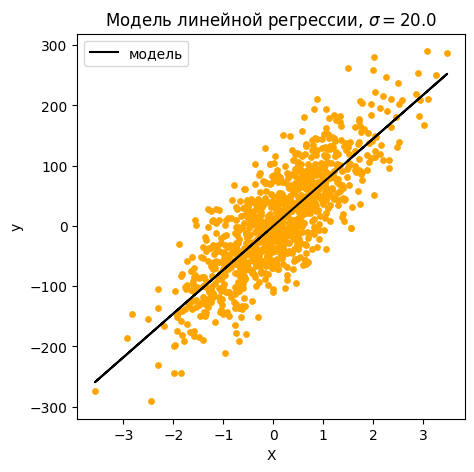

In [2]:
X, y, coef = make_regression(n_samples=1000, n_features=2, noise=50.20, coef=True, random_state=38)

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.scatter(X[:,0], y, c='orange', s=15)
ax.plot(X[:,0],np.dot(coef[0], X[:,0]), '-', color='black', label='модель')
ax.legend(loc='upper left')
ax.set(xlabel='X',ylabel='y',title='Модель линейной регрессии, $\sigma=20.0$')
plt.show();

In [3]:
X

array([[-0.13704026, -1.64354232],
       [-1.31144302, -0.371127  ],
       [ 1.33978064, -0.82179757],
       ...,
       [ 0.87482733, -1.18834488],
       [-1.26105775, -0.25739925],
       [ 1.49654781,  0.18412844]], shape=(1000, 2))

In [4]:
y.shape

(1000,)

In [5]:
coef

array([72.59456432,  0.47026977])

Обученная на <font color='blue'>обучающей выборке</font> модель должна предсказывать значения на некоторой неизвестной или <font color='blue'>тестовой выборке </font> данных. Работая здесь с искусственно сгенерированными данными, отделим $ 40 \% $ данных для тестирования. Эта процедура будет повторять и визуализировать полученные таким образом модели.

Для оценки качества модели, можно использовать метрики реализованные в Sciki-Learn: [Regression metrics](http://scikit-learn.org/stable/modules/classes.html#regression-metrics)); 
[`sklearn.metrics.explained_variance_score`](http://scikit-learn.org/stable/modules/generated/sklearn.metrics.explained_variance_score.html);
[`sklearn.metrics.r2_score`](http://scikit-learn.org/stable/modules/generated/sklearn.metrics.r2_score.html#sklearn.metrics.r2_score);
[`sklearn.linear_model.LinearRegression`](http://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html#sklearn.linear_model.LinearRegression).

Метод наименьших квадратов дает байесовское оптимальное решение, предполагая, что фактическая модель линейна и что шум в целевом векторе $ y $ нормально распределен. Это предположение может быть визуально проверено путем нахождения вычетов - отклонений от прогнозируемого значения $ \hat {y} $ для каждого наблюдения из обучающей выборки.

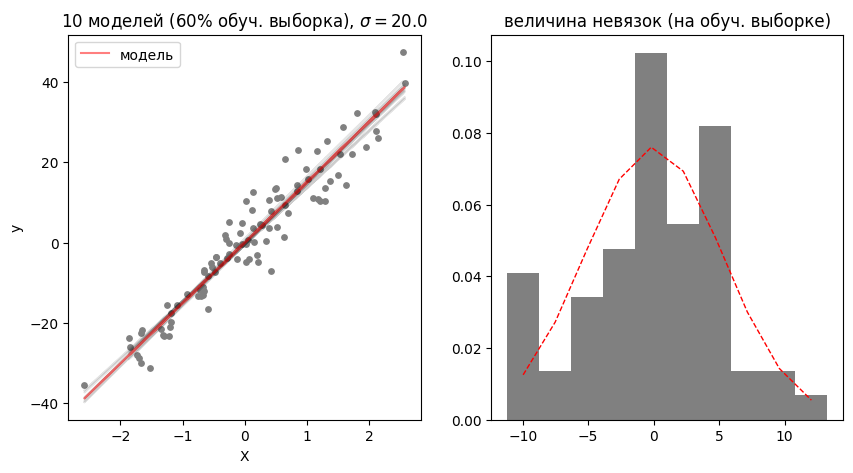

Объяснённая дисперсия: 0.90


In [6]:
X, y, coef = make_regression(n_samples=100, n_features=1, noise=5.0, coef=True, random_state=38)
# X, y, coef = make_regression(n_samples=3000, n_features=1, noise=20.0, coef=True, random_state=38)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].scatter(X, y, c='gray', s=15)

for temp in range(10):

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4) # , random_state=42)

    model = Pipeline([('linear', LinearRegression())])
    model.fit(X_train, y_train)
    
    ax[0].plot(X_train,model.predict(X_train), '-', color='black', alpha=0.1) #, label='linearni model')

ax[0].plot(X,np.dot(coef,X), '-', color='red', alpha=0.5, label='модель')
ax[0].set(xlabel='X',ylabel='y',title='10 моделей (60% обуч. выборка), $\sigma=20.0$')
ax[0].legend(loc='upper left')

from numpy import *
def normpdf(x, mu, sigma):
    u = (x-mu)/abs(sigma)
    y = (1/(sqrt(2*pi)*abs(sigma)))*exp(-u*u/2)
    return y

# Residuals
residuals = model.predict(X_train)-y_train
n, bins, patches = ax[1].hist(residuals, bins=10, density=True, color='gray')
bincenters = 0.5*(bins[1:]+bins[:-1])
y_norm = normpdf(bincenters, np.mean(residuals), np.std(residuals))
ax[1].plot(bincenters, y_norm, 'r--', linewidth=1, label='gaussian')
ax[1].set(title='величина невязок (на обуч. выборке)')
plt.show();
print('Объяснённая дисперсия: ' + '{0:.2f}'.format(explained_variance_score(y_train,model.predict(X_train))))

### Загрузим реальный набор данных и построим модель линейной регрессии

В рамках данного учебного проекта мы используем классический Бостонский датасет, содержащий 13 числовых признаков, однако для целей обучения и абстрагирования от предметной области недвижимости мы адаптируем его под медицинские задачи. Все признаки получают абстрактные обозначения (от X0 до X12), а целевая переменная интерпретируется как некий медицинский показатель, позволяя имитировать анализ данных пациентов, например, с сахарным диабетом. Такой подход позволяет сосредоточиться на математическом аппарате линейной регрессии и алгоритмах машинного обучения, не отвлекаясь на специфику и этические проблемы исходных данных о ценах на жилье.

In [7]:
# загружаем данные напрямую из источника
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)

# разбираем специфическую структуру файла
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

# преобразуем в DataFrame с абстрактными названиями X0-X12 и 13-й целевой переменной target
diabetes = pd.DataFrame(data=np.c_[data, target], columns=np.append(['X'+str(i) for i in range(data.shape[1])], 'target'))
diabetes.head()

,X0,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,target
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


In [8]:
# описательный анализ данных
diabetes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X0      506 non-null    float64
 1   X1      506 non-null    float64
 2   X2      506 non-null    float64
 3   X3      506 non-null    float64
 4   X4      506 non-null    float64
 5   X5      506 non-null    float64
 6   X6      506 non-null    float64
 7   X7      506 non-null    float64
 8   X8      506 non-null    float64
 9   X9      506 non-null    float64
 10  X10     506 non-null    float64
 11  X11     506 non-null    float64
 12  X12     506 non-null    float64
 13  target  506 non-null    float64
dtypes: float64(14)
memory usage: 55.5 KB


### Для облегчения визуализации выберем один признак, на котором рассмотрим поведение линейной модели.

In [9]:
# из датасета откинем целевой столбец и выведем корреляцию целевого столбца с остальными 12-ю признаками
diabetes.drop('target', axis=1).corrwith(diabetes['target']).sort_values(ascending=False).round(2)

X5     0.70
X1     0.36
X11    0.33
X7     0.25
X3     0.18
X6    -0.38
X8    -0.38
X0    -0.39
X4    -0.43
X9    -0.47
X2    -0.48
X10   -0.51
X12   -0.74
dtype: float64

**Вывод:** наблюдается сильная прямая корреляция целевого признака с признаком Х5 (0.70) и сильная обратная корреляция целевого признака с признаком Х12 (-0.74).

In [10]:
# создаём тестовую и тренировочную выборки в размере 20% от исходного датасета
# задаём значение генерируемых псевдослучайных величин равным 42 для получения одинаковых данных на тренировочной и тестовой выборках
diabetes_train, diabetes_test = train_test_split(diabetes[['X12','target']], test_size=0.2, random_state=42)

# создаём пайплайн для хранения всех этапов рабочего процесса в виде единого объекта
model = Pipeline([('linear', LinearRegression())])

# вызываем объект с помощью метода fit, запускаем автоматическое выполнение шагов препроцессинга
# убираем столбец с целевым признаком из датасета, чтобы избежать переобучения модели 
model = model.fit(diabetes_train.drop('target', axis=1), diabetes_train['target'])

# создаём модель прогнозирования выходных данных
diabetes_target_pred = model.predict(diabetes_test.drop('target', axis=1))

### Оценка эффективности модели ML на основе линейной регресии

$R^2$ (коэффициент детерминации) — это один из показателей оценки эффективности модели машинного обучения на основе регрессии. Коэффициент детерминации обозначает совокупную прогнозирующую способность модели в диапазоне от -inf до 1,00, где 1,00 означает, что есть идеальное совпадение. При этом, совпадение может быть произвольно плохим, поэтому оценки могут быть отрицательными.

In [11]:
# оценка эффективности модели: коэффициент детерминации
R2 = r2_score(diabetes_test['target'], diabetes_target_pred)
R2

0.5429180422970386

Вычислим $MSE$ (Mean Square Error) — меру количества ошибок, которые наша линейная регрессия делает на наборе данных с помощью функции mean_squared_error (берутся все значения ошибок, считаются их квадраты длин и усредняются). Для создания качественно лучшей модели необходимо минимизировать MSE.

In [12]:
# оценка эффективности модели: среднеквадратичная ошибка
MSE = mean_squared_error(diabetes_test['target'], diabetes_target_pred)
MSE

33.51954917268488

Разность между фактическим и вычисленным значением зависимой переменной $f(x_i) - y_i$ называется невязкой. Вектор невязок 
обозначается $f(x) - y$. Этот вектор также называется вектором регрессионных остатков (residuals).

In [13]:
# оценка эффективности модели: величина невязок
residuals = model.predict(diabetes_train.drop('target', axis=1)) - diabetes_train['target']

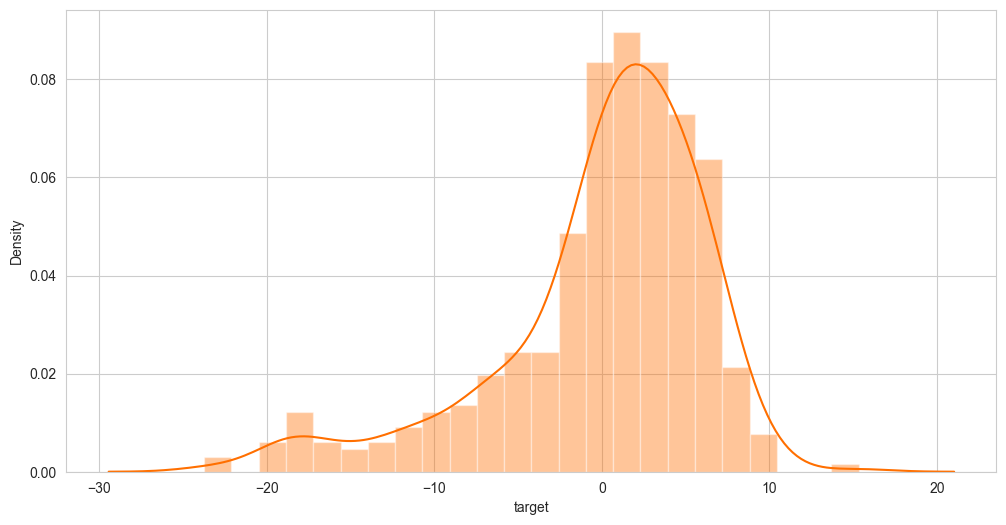

In [14]:
# оценка эффективности модели: распределение плотности значений величины невязок
plt.figure(figsize=(12, 6))
sns.set_style('whitegrid', {'axes.grid' : True})
sns.distplot(residuals, color='#FF6F00')

plt.show()

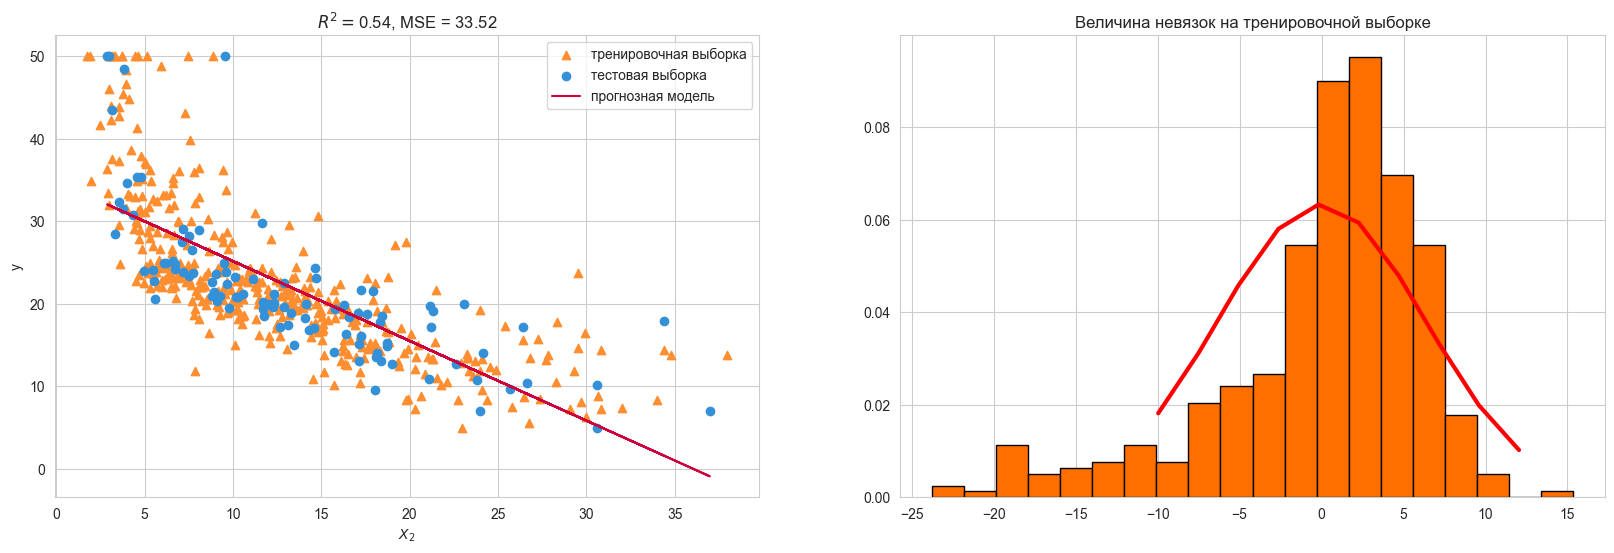

In [15]:
# визуализация данных: выводим два графика ax[0] и ax[1]
# график ax[0]: на одном поле выводим диаграммы рассеяния тренировочной выборки (оранжевые треугольники) и тестовой выборки (синие точки), двумерный график (красная линия) прогнозной модели 
fig, ax = plt.subplots(1,2, figsize=(20, 6))

ax[0].scatter(diabetes_train.drop('target', axis=1).values, diabetes_train['target'], color='#FF8E30', marker='^', label='тренировочная выборка')
ax[0].scatter(diabetes_test.drop('target', axis=1).values, diabetes_test['target'], color='#3491D8', marker='o', label='тестовая выборка')
ax[0].plot(diabetes_test.drop('target', axis=1).values, diabetes_target_pred, color='#CE003B', label='прогнозная модель')

# график ax[0]: сверху слева выводим расчётные значения R^2 и MSE
ax[0].set(title = '$R^2 = $' + '{0:.2f}'.format(R2) + ', MSE = ' + '{0:.2f}'.format(MSE))
ax[0].set(xlabel = '$X_2$', ylabel = 'y')
ax[0].legend(loc = 'upper right')

# график ax[1]: распределение плотности значений величины невязок на тренировочной выборке

# устанавливаем бинаризатор для данных
bincenters = 0.5 * (bins[1:] + bins[:-1])

# нормализуем значения среднего и стандартного отклонения величины невязок с помощью функции плотности вероятности (Probability density function), которая может возвращать значения больше единицы
y_norm = norm.pdf(bincenters, np.mean(residuals), np.std(residuals))

n, bins, patches = ax[1].hist(residuals, bins=20, density=True, color='#FF6F00', edgecolor='black')
ax[1].plot(bincenters, y_norm, 'r-', linewidth=3, label='gaussian')
ax[1].set(title='Величина невязок на тренировочной выборке')

plt.show()

In [16]:
diabetes_train.drop('target', axis=1).values

array([[24.91],
       [ 8.47],
       [ 7.83],
       [23.29],
       [11.28],
       [ 5.08],
       [ 8.01],
       [ 5.77],
       [26.45],
       [19.78],
       [ 6.75],
       [ 9.45],
       [ 6.36],
       [15.17],
       [ 7.56],
       [16.51],
       [12.01],
       [ 6.36],
       [12.5 ],
       [ 5.9 ],
       [20.62],
       [10.3 ],
       [ 5.81],
       [ 7.7 ],
       [ 6.36],
       [ 4.82],
       [15.02],
       [ 3.76],
       [27.26],
       [ 7.34],
       [13.04],
       [17.09],
       [28.32],
       [12.03],
       [ 8.51],
       [ 3.95],
       [ 4.38],
       [16.3 ],
       [14.67],
       [ 4.97],
       [10.24],
       [23.98],
       [27.38],
       [10.59],
       [15.12],
       [19.52],
       [19.88],
       [ 4.63],
       [16.22],
       [16.44],
       [ 5.21],
       [12.04],
       [10.21],
       [ 6.58],
       [18.13],
       [ 7.79],
       [ 2.94],
       [22.98],
       [13.15],
       [13.15],
       [13.  ],
       [ 6.87],
       [

In [17]:
# объяснённая диспресия результирующего показателя - это выборочная дисперсия расчётных значений величины
explained_variance = explained_variance_score(diabetes_train['target'], model.predict(diabetes_train.drop('target', axis=1)))
print('Объяснённая дисперсия: ' + '{0:.2f}'.format(explained_variance))

Объяснённая дисперсия: 0.54


In [18]:
# вычислим стандартное отклонение для измерения величины вариации в наборе данных относительно его среднего значения
np.std(residuals)

6.305583781829742

In [19]:
# коэффициент модели линейной регрессии для выбранного признака X12
print(model.named_steps['linear'].coef_)

[-0.9665309]


### Построим модель данных на полном наборе признаков.

In [20]:
diabetes_train, diabetes_test = train_test_split(diabetes, test_size=0.75, random_state=42)

model = Pipeline([('linear', LinearRegression())])
model = model.fit(diabetes_train.drop('target', axis=1), diabetes_train['target'])

diabetes_target_pred = model.predict(diabetes_test.drop('target', axis=1))

R2 = r2_score(diabetes_test['target'], diabetes_target_pred) 
MSE = mean_squared_error(diabetes_test['target'], diabetes_target_pred) 

print('R2 = '+'{0:.2f}'.format(R2)+', MSE = '+'{0:.2f}'.format(MSE))

plt.show()

R2 = 0.72, MSE = 24.83


Объяснённая дисперсия: 0.72


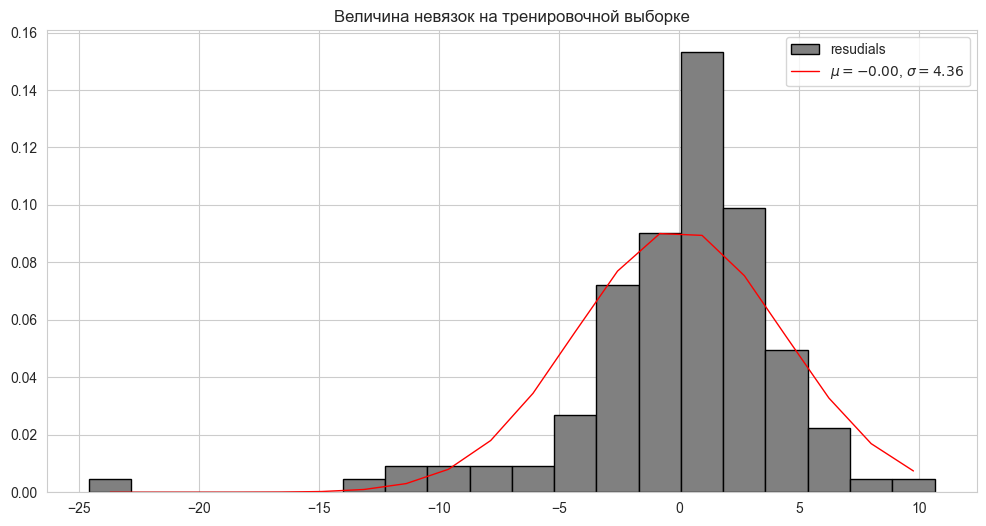

In [21]:
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

residuals = model.predict(diabetes_train.drop('target', axis=1)) - diabetes_train['target']

n, bins, patches = ax.hist(residuals, bins=20, density=True, color='gray', edgecolor='black', label='resudials')

bincenters = 0.5*(bins[1:]+bins[:-1])
residuals_mu = np.mean(residuals)
residuals_std = np.std(residuals)
y_norm = norm.pdf(bincenters, residuals_mu, residuals_std )
l = ax.plot(bincenters, y_norm, 'r-', linewidth=1, label='$\mu='+'{0:.2f}'.format(residuals_mu)+'$, $\sigma='+'{0:.2f}'.format(residuals_std)+'$')
ax.set(title='Величина невязок на тренировочной выборке')
ax.legend(loc='upper right')

explained_variance = explained_variance_score(diabetes_train['target'],model.predict(diabetes_train.drop('target', axis=1)))
print('Объяснённая дисперсия: ' + '{0:.2f}'.format(explained_variance))

plt.show()

In [22]:
# коэффициенты модели линейной регрессии для всех признаков, включая X12
for i in zip(diabetes.drop('target',axis=1).columns, model.named_steps['linear'].coef_):
    print(i)

('X0', np.float64(-0.16803071161552474))
('X1', np.float64(0.017319990664781282))
('X2', np.float64(0.12441510429034562))
('X3', np.float64(3.26709823880361))
('X4', np.float64(-17.662422472913907))
('X5', np.float64(4.474717096855503))
('X6', np.float64(-0.017833513005983126))
('X7', np.float64(-1.0558396862211707))
('X8', np.float64(0.20271152321187275))
('X9', np.float64(-0.0031221135804244127))
('X10', np.float64(-1.1221142851849488))
('X11', np.float64(0.011354274508376784))
('X12', np.float64(-0.42291732506953766))


In [23]:
X = diabetes[['X1', 'X11', 'X7', 'X3', 'X6', 'X8', 'X0', 'X4', 'X9', 'X2']]
y = diabetes['target']

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.85, random_state=40)

In [25]:
lm = LinearRegression()

In [26]:
lm.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [27]:
# чем больше значение, тем больше оно связано с целевым признаком
lm.coef_

array([ 1.47531878e-01,  7.08459787e-03, -3.34436298e+00, -1.58154269e+00,
       -1.17319779e-01,  2.19117820e-01, -2.60940143e-01, -1.45423045e+01,
       -2.52266630e-02, -1.59915583e-01])

In [28]:
y_pred = lm.predict(X_test)

In [29]:
import sklearn.metrics as metrics
acc = metrics.mean_squared_error(y_test,y_pred)
np.sqrt(acc)

np.float64(7.465710409132153)

358    9.350398
197    0.705458
48    -2.704594
450    0.579319
469    1.655214
         ...   
357    8.190797
36    -8.008095
83    -4.832766
456   -0.419200
57     0.198651
Name: target, Length: 431, dtype: float64

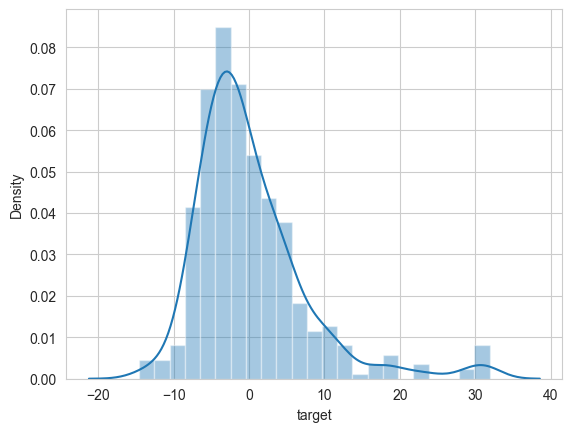

In [30]:
sns.distplot((y_test - y_pred))

residuals = (y_test - y_pred)
residuals

In [31]:
# качество модели
R2 = r2_score(y_test, y_pred)
MSE = mean_squared_error(y_test, y_pred)

display(R2)
display(MSE)

0.3504552143031441

55.736831913024176

### Заключение

Нами был полностью пройден цикл построения и оценки моделей линейной регрессии: от генерации синтетических данных до анализа сложных многомерных зависимостей. На первом этапе, работая с искусственно сгенерированными наборами данных, мы визуально и статистически подтвердили ключевые допущения метода наименьших квадратов (МНК). В частности, мы убедились в том, что невязки модели (отклонения фактических значений от предсказанных) подчиняются нормальному закону распределения. Это является критически важным условием для корректной работы классической линейной регрессии и достоверности получаемых оценок.

Переходя к анализу адаптированного «медицинского» датасета, мы начали с построения простой линейной регрессии, используя единственный признак `X12`, который продемонстрировал наиболее сильную обратную корреляцию с целевой переменной (коэффициент корреляции составил -0.74). Даже такая упрощенная модель оказалась способна объяснить более половины дисперсии целевого показателя (коэффициент детерминации R² достиг 0.54), а анализ невязок подтвердил их приближенность к гауссовскому распределению. Однако среднеквадратичная ошибка (`MSE`) на уровне 33.52 указывала на то, что для более точного описания процесса необходимо учитывать влияние дополнительных факторов.

Закономерным шагом стало обучение множественной линейной регрессии на полном наборе из 13 абстрактных признаков. Как и ожидалось, усложнение модели привело к существенному росту её предсказательной силы: значение `R²` увеличилось до 0.72, а ошибка `MSE` снизилась до 24.83. Анализ весовых коэффициентов показал, что модель успешно выявила скрытые паттерны, присвоив наибольшее математическое влияние тем переменным, которые сильнее всего воздействовали на целевой показатель.

Особый интерес представляет финальный эксперимент, в котором мы намеренно исключили из модели два наиболее сильных предиктора (X5 и X12), оставив 10 менее значимых признаков, и при этом увеличили долю тестовой выборки до 85%. Результаты оказались крайне показательными: качество модели катастрофически упало (R² снизился до 0.35, а MSE вырос более чем в два раза — до 55.74, при RMSE около 7.47). Этот наглядный пример демонстрирует фундаментальное правило машинного обучения: механическое увеличение объема тестовых данных не гарантирует высокого качества прогноза, если из модели удаляются ключевые факторы, несущие основную информативную нагрузку. Попытка обойтись без сильных предикторов привела к сильному недообучению модели.

В заключение следует сказать, что данный проект позволил нам не только освоить технический инструментарий библиотек `Python` (создание пайплайнов `scikit-learn`, грамотное разделение выборок, расчёт регрессионных метрик), но и глубоко понять философию регрессионного анализа. Мы убедились, что линейная регрессия, несмотря на свою кажущуюся простоту, остается мощным и гибким инструментом, требующим внимательного отношения как к проверке статистических допущений, так и к грамотному отбору признаков, от которых напрямую зависит способность модели делать точные прогнозы на новых данных.